<a href="https://colab.research.google.com/github/Ananya1812-iilm/Ananya_Pradhan_25SCS1003000489_IILM_GN/blob/main/Forcasting_SmartCity_TrafficPatterns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving dataset.csv to dataset (1).csv


In [ ]:
df = pd.read_csv('dataset.csv')

In [ ]:
df.head()

,DateTime,Junction,Vehicles,ID
0,01-11-2015 00:00,1,15,20151101001
1,01-11-2015 01:00,1,13,20151101011
2,01-11-2015 02:00,1,10,20151101021
3,01-11-2015 03:00,1,7,20151101031
4,01-11-2015 04:00,1,9,20151101041


In [ ]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)


Dataset Shape:
(48120, 13)

Column Names:
Index(['DateTime', 'Junction', 'Vehicles', 'ID', 'Year', 'Month', 'Day',
       'Hour', 'Weekday', 'Weekend', 'Holiday', 'Minute', 'DayOfWeek'],
      dtype='object')


In [ ]:
print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
Index: 48120 entries, 29184 to 43775
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   DateTime   48120 non-null  datetime64[ns]
 1   Junction   48120 non-null  int64         
 2   Vehicles   48120 non-null  int64         
 3   ID         48120 non-null  int64         
 4   Year       48120 non-null  int32         
 5   Month      48120 non-null  int32         
 6   Day        48120 non-null  int32         
 7   Hour       48120 non-null  int32         
 8   Weekday    48120 non-null  object        
 9   Weekend    48120 non-null  int64         
 10  Holiday    48120 non-null  object        
 11  Minute     48120 non-null  int32         
 12  DayOfWeek  48120 non-null  int32         
dtypes: datetime64[ns](1), int32(6), int64(4), object(2)
memory usage: 4.0+ MB
None

Missing Values
DateTime     0
Junction     0
Vehicles     0
ID           0
Year  

In [ ]:
df['DateTime'] = pd.to_datetime(df['DateTime'],format='%d-%m-%Y %H:%M')
df = df.sort_values('DateTime')

In [ ]:
df.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,Weekday,Weekend,Holiday,Minute,DayOfWeek
29184,2015-11-01 00:00:00,3,9,20151101003,2015,11,1,0,Sunday,1,Ellipsis,0,6
14592,2015-11-01 00:00:00,2,6,20151101002,2015,11,1,0,Sunday,1,Ellipsis,0,6
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,Sunday,1,Ellipsis,0,6
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,Sunday,1,Ellipsis,0,6
14593,2015-11-01 01:00:00,2,6,20151101012,2015,11,1,1,Sunday,1,Ellipsis,0,6


In [ ]:
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour
df['Minute'] = df['DateTime'].dt.minute
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df['Week'] = df['DateTime'].dt.isocalendar().week.astype(int)
df['Weekend'] = np.where(df['DayOfWeek']>=5,1,0)

print(df.head())

                 DateTime  Junction  Vehicles           ID  Year  Month  Day  \
29184 2015-11-01 00:00:00         3         9  20151101003  2015     11    1   
14592 2015-11-01 00:00:00         2         6  20151101002  2015     11    1   
0     2015-11-01 00:00:00         1        15  20151101001  2015     11    1   
1     2015-11-01 01:00:00         1        13  20151101011  2015     11    1   
14593 2015-11-01 01:00:00         2         6  20151101012  2015     11    1   

       Hour Weekday  Weekend   Holiday  Minute  DayOfWeek  Week  
29184     0  Sunday        1  Ellipsis       0          6    44  
14592     0  Sunday        1  Ellipsis       0          6    44  
0         0  Sunday        1  Ellipsis       0          6    44  
1         1  Sunday        1  Ellipsis       0          6    44  
14593     1  Sunday        1  Ellipsis       0          6    44  


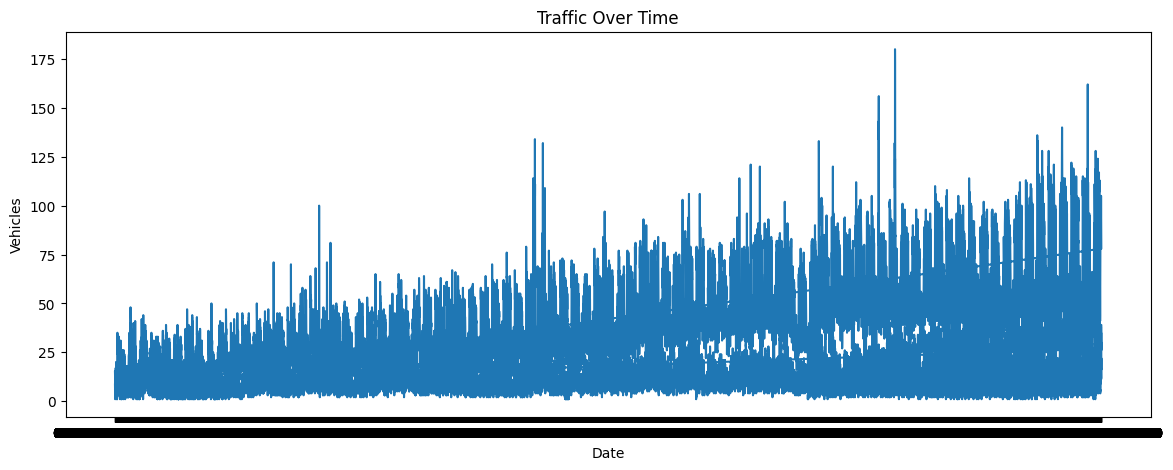

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df['DateTime'],df['Vehicles'])
plt.title("Traffic Over Time")
plt.xlabel("Date")
plt.ylabel("Vehicles")
plt.show()

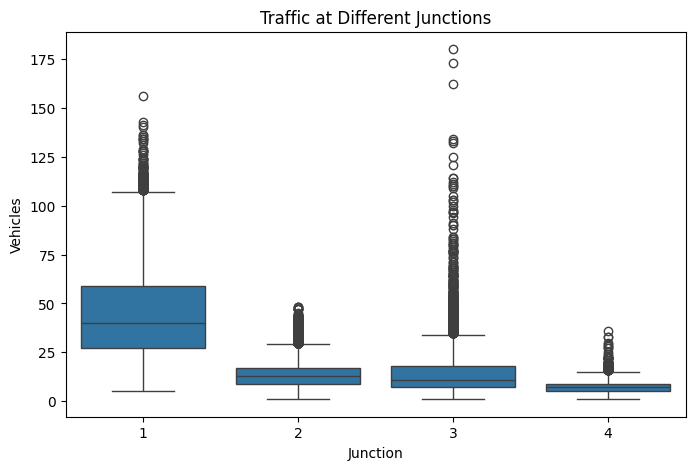

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Junction',y='Vehicles',data=df)
plt.title("Traffic at Different Junctions")
plt.show()

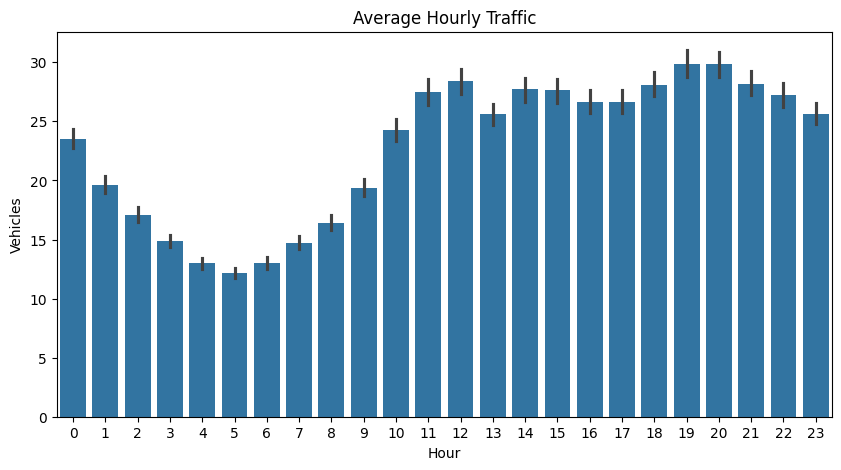

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Hour',y='Vehicles',data=df)
plt.title("Average Hourly Traffic")
plt.show()

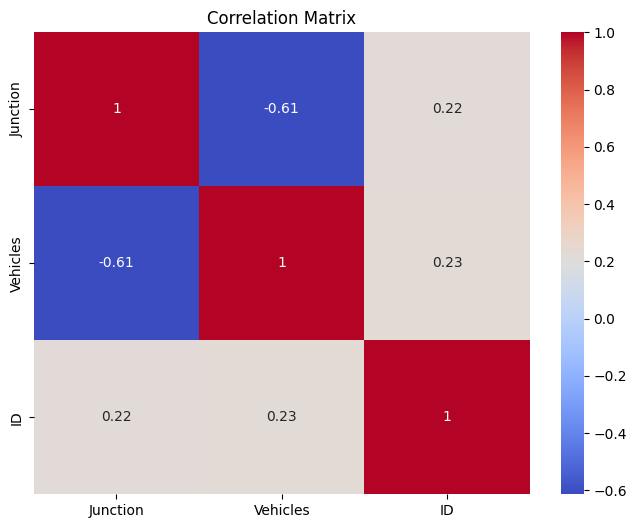

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df['DateTime'] = pd.to_datetime(df['DateTime'],format='%d-%m-%Y %H:%M')
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour
df['Minute'] = df['DateTime'].dt.minute
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df['Week'] = df['DateTime'].dt.isocalendar().week.astype(int)
df['Weekend'] = np.where(df['DayOfWeek']>=5,1,0)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("\nModel Evaluation")
print("-------------------------")
print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 Score :",r2)


Model Evaluation
-------------------------
MAE : 2.437492726517041
MSE : 16.049051844347463
RMSE : 4.006126788351495
R2 Score : 0.9632712767335108


In [ ]:
comparison = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":np.round(y_pred,2)
})

print("\nComparison")
print(comparison.head(20))


Comparison
    Actual  Predicted
0       10       9.22
1       39      38.56
2       53      58.80
3       66      65.88
4        6       8.61
5       11      10.92
6       38      32.24
7        4       3.06
8        8       5.60
9       38      46.67
10      36      39.06
11       9      13.22
12       5       6.76
13      46      42.60
14      18      18.24
15      24      12.02
16      13      13.52
17      12       9.40
18      31      33.03
19       9       8.34


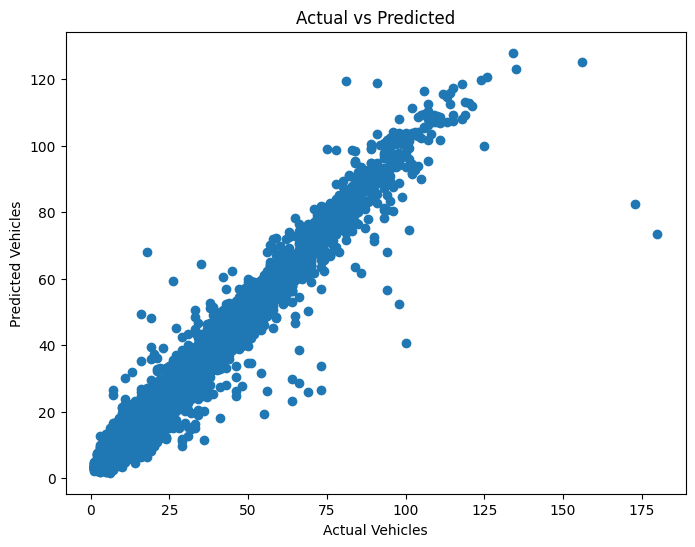

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Vehicles")
plt.ylabel("Predicted Vehicles")
plt.title("Actual vs Predicted")
plt.show()

     Feature  Importance
0   Junction    0.516721
1       Year    0.164756
4       Hour    0.144869
6  DayOfWeek    0.043306
2      Month    0.040657
7       Week    0.038132
8    Weekend    0.030013
3        Day    0.021545
5     Minute    0.000000


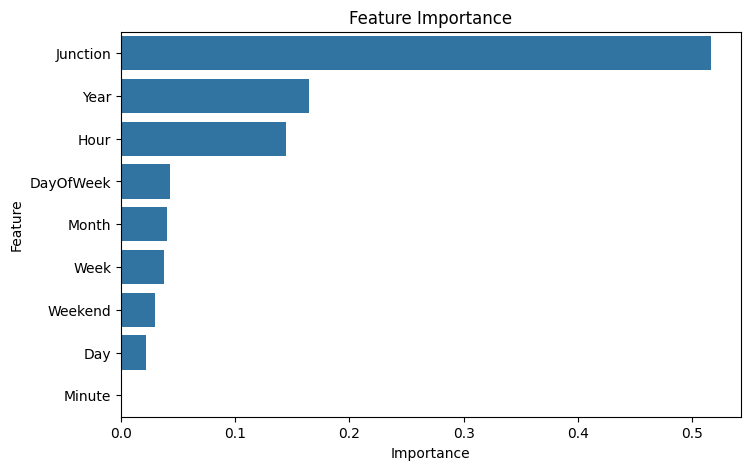

In [ ]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance")
plt.show()

In [ ]:
new_data = pd.DataFrame({

'Junction':[2],
'Year':[2017],
'Month':[12],
'Day':[25],
'Hour':[18],
'Minute':[0],
'DayOfWeek':[0],
'Week':[52],
'Weekend':[0]

})

prediction = model.predict(new_data)

print("\nPredicted Vehicles :",round(prediction[0]))


Predicted Vehicles : 37


In [ ]:
last_date = df['DateTime'].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(hours=1),
    periods=24,
    freq='h'
)

forecast_list = []

for junction in sorted(df['Junction'].unique()):

    future = pd.DataFrame()

    future['DateTime'] = future_dates

    future['Junction'] = junction

    future['Year'] = future['DateTime'].dt.year
    future['Month'] = future['DateTime'].dt.month
    future['Day'] = future['DateTime'].dt.day
    future['Hour'] = future['DateTime'].dt.hour
    future['Minute'] = future['DateTime'].dt.minute
    future['DayOfWeek'] = future['DateTime'].dt.dayofweek
    future['Week'] = future['DateTime'].dt.isocalendar().week.astype(int)
    future['Weekend'] = np.where(future['DayOfWeek']>=5,1,0)

    X_future = future[['Junction',
                       'Year',
                       'Month',
                       'Day',
                       'Hour',
                       'Minute',
                       'DayOfWeek',
                       'Week',
                       'Weekend']]

    future['Forecasted_Vehicles'] = model.predict(X_future)

    forecast_list.append(future)

forecast = pd.concat(forecast_list)

print("\nForecast")
print(forecast.head())


Forecast
             DateTime  Junction  Year  Month  Day  Hour  Minute  DayOfWeek  \
0 2017-07-01 00:00:00         1  2017      7    1     0       0          5   
1 2017-07-01 01:00:00         1  2017      7    1     1       0          5   
2 2017-07-01 02:00:00         1  2017      7    1     2       0          5   
3 2017-07-01 03:00:00         1  2017      7    1     3       0          5   
4 2017-07-01 04:00:00         1  2017      7    1     4       0          5   

   Week  Weekend  Forecasted_Vehicles  
0    26        1               69.415  
1    26        1               60.600  
2    26        1               46.435  
3    26        1               37.835  
4    26        1               32.955  


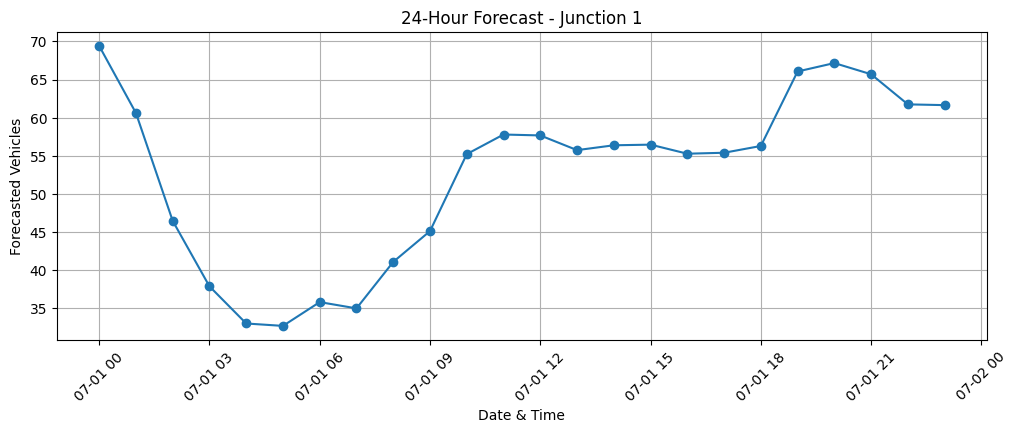

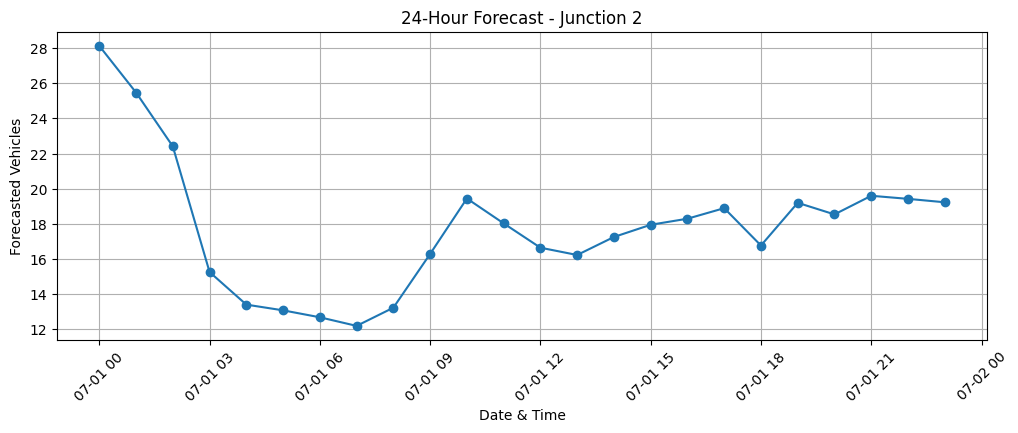

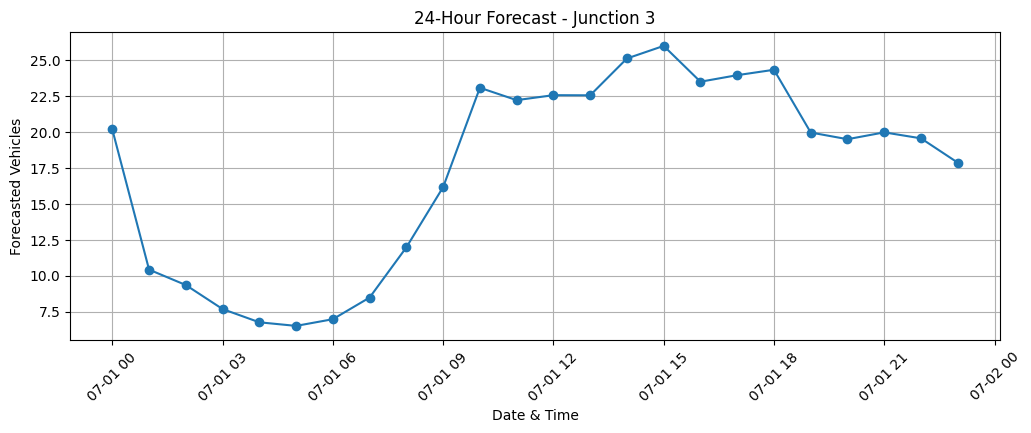

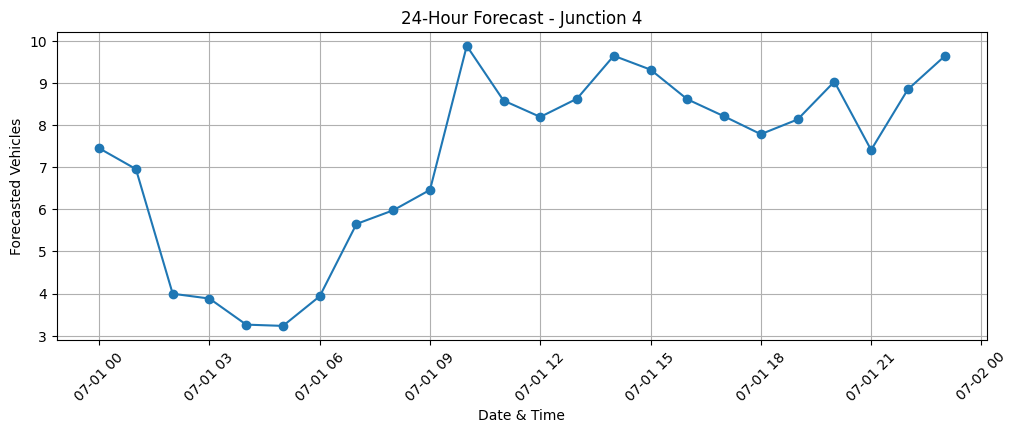

In [ ]:
for junction in sorted(forecast['Junction'].unique()):

    temp = forecast[forecast['Junction']==junction]

    plt.figure(figsize=(12,4))

    plt.plot(
        temp['DateTime'],
        temp['Forecasted_Vehicles'],
        marker='o'
    )

    plt.title(f"24-Hour Forecast - Junction {junction}")

    plt.xlabel("Date & Time")

    plt.ylabel("Forecasted Vehicles")

    plt.xticks(rotation=45)

    plt.grid(True)

    plt.show()


In [ ]:
forecast.to_csv("Traffic_Forecast.csv",index=False)

print("\nTraffic forecast saved successfully!")

print(forecast.head(20))


Traffic forecast saved successfully!
              DateTime  Junction  Year  Month  Day  Hour  Minute  DayOfWeek  \
0  2017-07-01 00:00:00         1  2017      7    1     0       0          5   
1  2017-07-01 01:00:00         1  2017      7    1     1       0          5   
2  2017-07-01 02:00:00         1  2017      7    1     2       0          5   
3  2017-07-01 03:00:00         1  2017      7    1     3       0          5   
4  2017-07-01 04:00:00         1  2017      7    1     4       0          5   
5  2017-07-01 05:00:00         1  2017      7    1     5       0          5   
6  2017-07-01 06:00:00         1  2017      7    1     6       0          5   
7  2017-07-01 07:00:00         1  2017      7    1     7       0          5   
8  2017-07-01 08:00:00         1  2017      7    1     8       0          5   
9  2017-07-01 09:00:00         1  2017      7    1     9       0          5   
10 2017-07-01 10:00:00         1  2017      7    1    10       0          5   
11 2017-07-01 